# §3.2 What characteristics do upgrade-requiring substations share?

This notebook answers the question of §3.2 of the paper: among the substations whose duty-to-serve-robust (DSR) peak e-HDT charging load exceeds the 3 MW upgrade threshold, what land-use characteristics do they have in common? We apply the Patient Rule Induction Method (PRIM) to the count of business establishments (by NAICS industry) within each substation territory to find the employment patterns that best predict a high robust peak load.

**Generates:** the data behind the manuscript's PRIM employment-thresholds **table** (*"Employment thresholds identified by PRIM for substation territories without a truck stop"*), plus the per-substation employment counts and percentile **ranks cited in the §3.2 text** for the four example substations. This notebook produces no standalone figures — the Bay Area map discussed in §3.2 is **Figure 7**, exported from notebook `3.1.1`.

## Load modules

In [1]:
from prim import Prim

from laurel.scenario_builders.sense import SenseScenarioReader
from laurel.utils.h3 import H3_CRS, cells_to_region_polygons
from laurel.utils.params import tabularize_params

## Set global variables

The two **robustness policies** collapse each substation's distribution of peak loads across the 1,024 SoWs into a single planning level:

- **Duty-to-serve-robust (DSR)** — the 80th-percentile peak across SoWs (`DSR_THRESH = 0.8`): a conservative level the substation must serve in all but the 20% highest-demand futures.
- **Used-and-useful-robust (UUR)** — the 20th-percentile peak (`UUR_THRESH = 0.2`): a level reached in at least 80% of futures.

Within each SoW the peak is taken from the `PROF_QUANT = 0.95` (95th-percentile) load profile of the bootstrap samples. Throughout this notebook a substation "requires an upgrade" when its **DSR peak exceeds 3 MW**.

In [2]:
## Thresholds and robustness policies
UUR_THRESH = 0.2 # Used-and-useful-robust peak load threshold, only 20% fail to meet
DSR_THRESH = 0.8 # Duty-to-serve-robust peak load threshold, only 20% fail to exceed

PROF_QUANT = 0.95 # Quantile of the load profiles to use in evaluating robustness policies

In [3]:
## Substations to use as examples
EXAMP_SUBS = {
    9: "Newark - Urban Industrial",
    168: "Laytonville - Rural Highway",
    416: "Westley - Highway Truck Stop",
    422: "Tracy - Warehouses",
}

EXAMP_SUBS_REV = {v: k for k, v in EXAMP_SUBS.items()}

## Load data

In [4]:
%reload_ext kedro.ipython
%reload_kedro --params=data_dir=/scratch/users/passow/laurel/data --env=scenario_builders/sense_manage

[06/11/26 09:25:44] INFO     Using                                                                  ]8;id=617526;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=107012;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/fr                
                             amework/project/rich_logging.yml' as logging configuration.                           

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=586772;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=700840;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=794775;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=677650;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=532274;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=404219;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:25:46] INFO     Kedro project LAUREL                                                   ]8;id=520358;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=190865;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

...

[06/11/26 09:25:47] INFO     Registered line magic 'run_viz'                                        ]8;id=121448;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=812973;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=271231;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=12086;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:25:48] INFO     Kedro project LAUREL                                                   ]8;id=117920;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=703245;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=505648;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=173831;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=550234;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=755768;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [5]:
reader = SenseScenarioReader(dirs=["sense_manage"])

In [6]:
scen_params = catalog.load("params:scenario_params")
cfgs_parts = catalog.load("scenario_configs")
cfgs = reader.read_partitions(cfgs_parts)
read_keys = {k: v["path"] for k, v in scen_params["variables"].items()}
cfg_df = tabularize_params(
    cfgs=cfgs,
    read_keys=read_keys,
    idx_name=reader.scenario_name,
)
MANAGED_CHARGING_SCENS = cfg_df.loc[cfg_df["manage_charging"] == "MinPowerChargingManager"].index.values

                    INFO     Loading data from params:scenario_params (MemoryDataset)...       ]8;id=47912;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=488573;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from scenario_configs (PartitionedDataset)...        ]8;id=682302;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=562245;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [7]:
summs_subs_parts = catalog.load("substation.report_by_region_summaries_scenario")
summs_subs = reader.read_partitions(summs_subs_parts, lazy=True)

# Check for incomplete scenarios
incomplete = reader.list_completed_partitions(
    data_partitions=summs_subs_parts,
    config_partitions=cfgs_parts,
    incomplete=True,
    report_type="task",
)
print(f"# of incomplete: {len(incomplete)}")
print(f"incomplete ids: {incomplete}")

[06/11/26 09:26:01] INFO     Loading data from substation.report_by_region_summaries_scenario  ]8;id=288208;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=363055;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (PartitionedDataset)...                                                               

# of incomplete: 0
incomplete ids: []


In [8]:
hexes = catalog.load("hex_cluster_corresp")
hexes = hexes.dropna(subset=["substation_id"])
hexes["substation_id"] = hexes["substation_id"].astype(int)

[06/11/26 09:26:02] INFO     Loading data from hex_cluster_corresp (FeatherDataset)...         ]8;id=200430;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=558572;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [9]:
estabs_hex = catalog.load("estabs_pivoted")

[06/11/26 09:26:03] INFO     Loading data from estabs_pivoted (FeatherDataset)...              ]8;id=12513;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=214166;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

## Data preparation

### Preparing charging load profile summaries

For every substation we load the 95th-percentile peak load and median utilization for each SoW, then collapse the across-SoW distribution into the UUR (20th-pct) and DSR (80th-pct) robust levels defined above. Only **managed-charging** SoWs are kept (`MANAGED_CHARGING_SCENS`), matching the policy assumption used throughout the results section.

In [10]:
summs_subs_mem = summs_subs.loc[:, ["scenario", f"peak_kw_{PROF_QUANT}", "util_energy_0.5"]]
summs_subs_mem = summs_subs_mem.compute()

In [11]:
summs_subs_clean = summs_subs_mem.reset_index()
summs_subs_clean["substation_id"] = summs_subs_clean["substation_id"].astype(int)
summs_subs_clean = summs_subs_clean.set_index(["scenario", "substation_id"])

summs_subs_clean = summs_subs_clean.rename(columns={f"peak_kw_{PROF_QUANT}": "peak_load_kw", "util_energy_0.5": "util_energy"})
summs_subs_clean["peak_load_mw"] = summs_subs_clean["peak_load_kw"] / 1000
summs_subs_clean = summs_subs_clean.drop(columns=["peak_load_kw"])

In [12]:
threshes = [UUR_THRESH, DSR_THRESH]
columns = ["peak_load_mw", "util_energy"]

robust_subs = (
    summs_subs_clean
    .loc[MANAGED_CHARGING_SCENS]
    .groupby("substation_id")[columns]
    .quantile(q=threshes)
    .unstack(level=-1)
)

# Rename to your desired column names
renamer = {
    ("peak_load_mw", UUR_THRESH): "uur_peak_level",
    ("peak_load_mw", DSR_THRESH): "dsr_peak_level",
    ("util_energy", UUR_THRESH): "uur_util_level",
    ("util_energy", DSR_THRESH): "dsr_util_level",
}
robust_subs.columns = [renamer[col] for col in robust_subs.columns]

## What characteristics do upgrade-requiring substations share?

We treat each substation's **DSR peak load** as the outcome and its **employment by freight-intensive NAICS industry** (establishment counts aggregated from the TAZs in its territory) as candidate predictors. PRIM (the Patient Rule Induction Method) searches for a rule — a "box" of employment thresholds — that jointly maximizes the *coverage* of upgrade-requiring substations (DSR peak > 3 MW) and their *density* within the selected subspace.

### Across all substations

A first PRIM run over **all** substations confirms that the presence of a **truck stop** (NAICS 44719007) is by far the strongest predictor — it alone selects a high-density box (99% of substations containing a truck stop exceed 3 MW). But truck stops are a strong *sufficient*, not *necessary*, condition: they appear in only ~39% of high-load substations. We therefore set them aside in the next step to surface the secondary land-use predictors. Here, `box.select(...)` picks a point on the peeling trajectory (the coverage/density trade-off) and `box.show_details()` visualizes the selected box.

In [13]:
emp_hex = estabs_hex.drop(columns=["geometry", "state"])
emp_hex = emp_hex.merge(hexes["substation_id"].to_frame(), how="inner", on="hex_id")
emp_sub = emp_hex.groupby("substation_id").sum()

In [14]:
# Note: robust_subs was created by filtering for only managed charging scenarios 
naics_cols = emp_sub.columns.to_list()
emp_sub_prim = emp_sub.merge(robust_subs.loc[:, ["uur_peak_level", "dsr_peak_level"]], how="outer", left_index=True, right_index=True)
emp_sub_prim = emp_sub_prim.fillna(0.0)

In [15]:
output_col = "dsr_peak_level"
upgrade_level = 3

p = Prim(
    x=emp_sub_prim.loc[:, naics_cols],
    y=emp_sub_prim.loc[:, output_col],
    threshold=upgrade_level,
    threshold_type=">",
    mass_min=0.02,
)
box = p.find_box()
box.peeling_trajectory

,coverage,density,mean,res dim,mass
0,1.000000,0.127835,0.127835,0,1.000000
1,0.338591,0.986002,0.986002,1,0.043898
2,0.305543,0.994621,0.994621,2,0.039270
3,0.288568,0.995853,0.995853,3,0.037043
4,0.249211,0.998195,0.998195,4,0.031916
5,0.236293,0.998730,0.998730,5,0.030245
6,0.189124,1.000000,1.000000,5,0.024177


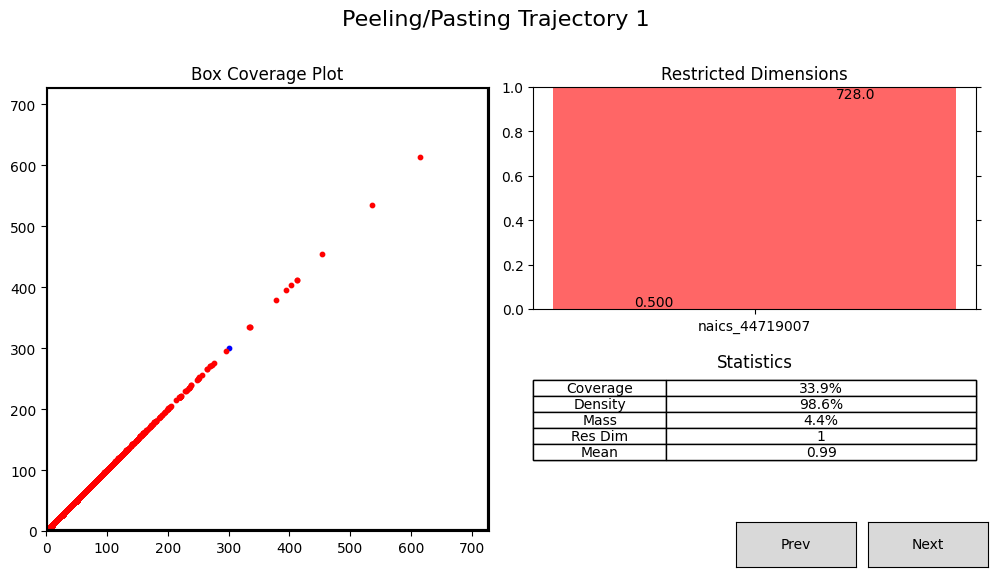

In [16]:
box.select(1)
box.show_details();

### Substation territories without a truck stop

Re-running PRIM after dropping truck-stop substations (and the truck-stop predictor) isolates the industrial and wholesale activity that characterizes the *remaining* high-load substations. We raise `mass_min` from 0.02 to 0.05 so the box retains enough substations to define a stable rule, then select the trajectory point (`box.select(12)`) that balances coverage and density. `box.show_tradeoff()` plots that trade-off curve to motivate the choice.

In [17]:
emp_sub_prim_no_stops = emp_sub_prim.loc[emp_sub_prim["naics_44719007"] == 0].drop(columns=["naics_44719007"])
naics_cols_no_stops = list(set(naics_cols).difference(["naics_44719007"]))

In [18]:
output_col = "dsr_peak_level"
upgrade_level = 3

p = Prim(
    x=emp_sub_prim_no_stops.loc[:, naics_cols_no_stops],
    y=emp_sub_prim_no_stops.loc[:, output_col],
    threshold=upgrade_level,
    threshold_type=">",
    mass_min=0.05,
)
box = p.find_box()
box.peeling_trajectory

,coverage,density,mean,res dim,mass
0,1.000000,0.088433,0.088433,0,1.000000
1,0.469680,0.387048,0.387048,1,0.107313
2,0.462639,0.461277,0.461277,2,0.088694
3,0.461276,0.485885,0.485885,3,0.083954
4,0.459914,0.510848,0.510848,3,0.079616
5,0.455598,0.532802,0.532802,3,0.075619
6,0.450375,0.554530,0.554530,4,0.071823
7,0.443107,0.574499,0.574499,4,0.068208
8,0.436521,0.597080,0.597080,4,0.064653
9,0.427209,0.617329,0.617329,4,0.061198


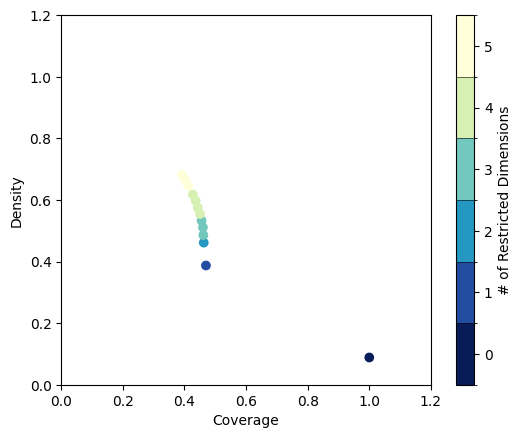

In [19]:
box.show_tradeoff();

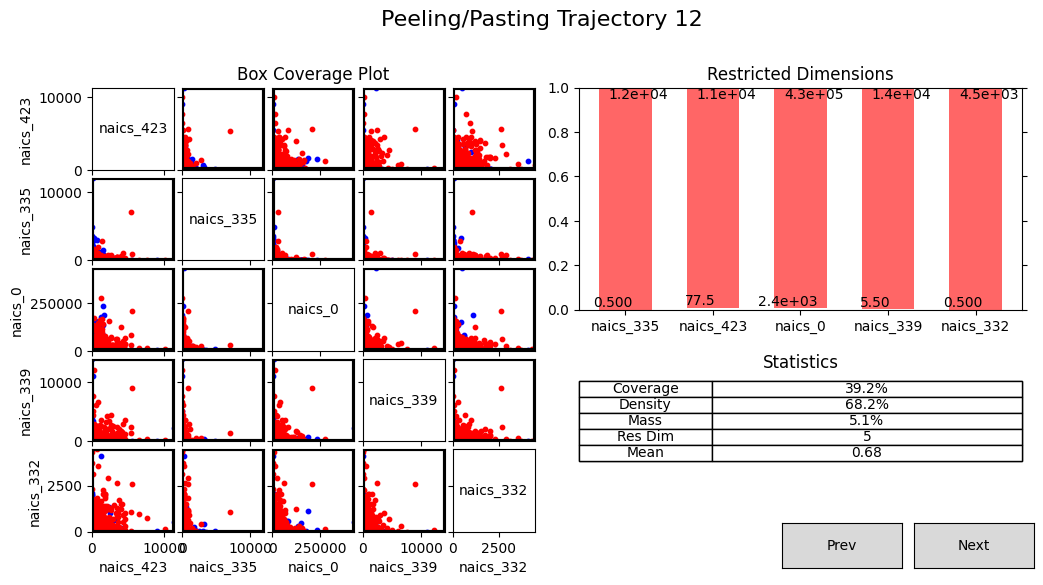

In [20]:
box.select(12)
box.show_details();

#### Table: PRIM employment thresholds (substations without a truck stop)

`box.limits` reports the employment thresholds defining the PRIM box — the data behind the manuscript's table *"Employment thresholds identified by PRIM for substation territories without a truck stop."* The rule covers ~39% of high-load no-truck-stop substations, of which ~68% exceed the 3 MW DSR threshold. The selected NAICS categories — electrical-equipment/appliance (335) and fabricated-metal (332) manufacturing, miscellaneous manufacturing (339), durable-goods wholesalers (423), and overall establishment count (0) — identify wholesale-trade and manufacturing activity as the secondary signature of upgrade-requiring substations.

In [21]:
box.limits

,min,max,qp values
naics_335,0.5,12015.0,2.930895e-28
naics_423,77.5,11336.0,3.960315e-14
naics_0,2415.0,431624.0,4.705526e-04
naics_339,5.5,14000.0,5.413514e-03
naics_332,0.5,4463.0,7.744174e-03


In [22]:
box.limits.index.to_list()

['naics_335', 'naics_423', 'naics_0', 'naics_339', 'naics_332']

### Example substations: values cited in the section text

For the four example substations (`EXAMP_SUBS`: Newark, Laytonville, Westley, Tracy) we report their raw employment counts (`disp_emp_levels`) and their percentile **ranks** among all substations (`disp_emp_ranks`) on the PRIM-selected NAICS categories. These are the values quoted in the §3.2 text to explain why each example does or does not fall inside the upgrade box.

In [23]:
emp_sub_rank = emp_sub_prim.rank(axis=0) / len(emp_sub_prim)

In [24]:
disp_emp_levels = emp_sub_prim.loc[list(EXAMP_SUBS.keys()), box.limits.index.to_list()]
disp_emp_levels.index = disp_emp_levels.index.map(EXAMP_SUBS)
disp_emp_levels.index.name = "substation_name"
disp_emp_levels

,naics_335,naics_423,naics_0,naics_339,naics_332
substation_name,,,,,
Newark - Urban Industrial,638.0,4035.0,37335.0,863.0,1502.0
Laytonville - Rural Highway,0.0,8.0,979.0,7.0,0.0
Westley - Highway Truck Stop,0.0,365.0,6904.0,5.0,1.0
Tracy - Warehouses,20.0,1736.0,20589.0,132.0,105.0


In [25]:
disp_emp_ranks = emp_sub_rank.loc[list(EXAMP_SUBS.keys()), box.limits.index.to_list()]
disp_emp_ranks.index = disp_emp_ranks.index.map(EXAMP_SUBS)
disp_emp_ranks.index.name = "substation_name"
disp_emp_ranks

,naics_335,naics_423,naics_0,naics_339,naics_332
substation_name,,,,,
Newark - Urban Industrial,0.998502,0.999578,0.993433,0.996601,0.999309
Laytonville - Rural Highway,0.444916,0.502208,0.580413,0.719443,0.302304
Westley - Highway Truck Stop,0.444916,0.950398,0.891119,0.688449,0.613346
Tracy - Warehouses,0.956102,0.996601,0.978253,0.957408,0.935026
